In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int
    discriminant: int
    equation: str
    result: str

In [3]:
def show_equation(state: QuadraticState):
    equation = f"{state['a']}x^2 + {state['b']}x + {state['c']} = 0"
    return {'equation': equation}

In [4]:
def calculate_discriminant(state: QuadraticState):
    a = state['a']
    b = state['b']
    c = state['c']
    discriminant = b**2 - 4*a*c
    return {'discriminant': discriminant}

In [7]:
def real_roots(state: QuadraticState):
    a = state['a']
    b = state['b']
    discriminant = state['discriminant']
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    result = f"The real roots are {root1} and {root2}"
    return {'result': result}

In [8]:
def repeated_roots(state: QuadraticState):
    a = state['a']
    b = state['b']
    root = -b / (2*a)
    result = f"The repeated root is {root}"
    return {'result': result}

In [ ]:
def no_real_roots(state: QuadraticState):
    return {'result': "There are no real roots."}

In [9]:
def check_condition(state: QuadraticState) -> Literal['real', 'repeated', 'none']:
    discriminant = state['discriminant']
    if discriminant > 0:
        return 'real_roots'
    elif discriminant == 0:
        return 'repeated_roots'
    else:
        return 'no_real_roots'

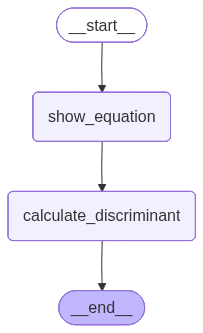

In [ ]:
graph = StateGraph(QuadraticState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('repeated_roots', repeated_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('calculate_discriminant', 'check_condition')
graph.add_edge('real_roots', END)
graph.add_edge('repeated_roots', END)
graph.add_edge('no_real_roots', END)

graph.compile()

In [6]:
initial_state = {
    'a': 4,
    'b': -5,
    'c': -4
}

workflow = graph.compile()

workflow.invoke(initial_state)

{'a': 4,
 'b': -5,
 'c': -4,
 'discriminant': 89,
 'equation': '4x^2 + -5x + -4 = 0'}